<a href="https://colab.research.google.com/github/ianvogel-glitch/Datascience_mkt/blob/main/Atividade_datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving campanhas_marketing_digital.csv to campanhas_marketing_digital.csv


In [3]:
import pandas as pd

df = pd.read_csv("campanhas_marketing_digital.csv")

df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data          24 non-null     object 
 1   canal         24 non-null     object 
 2   campanha      24 non-null     object 
 3   etapa_funil   24 non-null     object 
 4   investimento  24 non-null     int64  
 5   impressoes    24 non-null     int64  
 6   alcance       24 non-null     int64  
 7   cliques       24 non-null     int64  
 8   interacoes    24 non-null     int64  
 9   leads         23 non-null     float64
 10  conversoes    24 non-null     int64  
 11  receita       24 non-null     int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 2.4+ KB


### Análise inicial dos dados

Inicialmente, foi realizada a importação da base de dados utilizando a biblioteca Pandas. Em seguida, foram utilizadas as funções `head()` e `info()` para visualizar os primeiros registros e verificar a estrutura da base.

A base analisada possui **24 registros e 12 variáveis**. As colunas `data`, `canal`, `campanha` e `etapa_funil` foram identificadas como variáveis do tipo `object`, enquanto as demais apresentam valores numéricos, quanto de `int64` e `float64` . Apos a analise, a variável `leads` apresenta 23 valores não nulos, indicando a existência de **um valor ausente** nessa coluna. As outras variáveis possuem 24 valores não nulos.

Essa análise inicial permite conhecer a estrutura da base antes da realização do tratamento dos dados e do cálculo das métricas de desempenho das campanhas de marketing digital.


In [4]:
df["leads"]

,leads
0,150.0
1,118.0
2,72.0
3,64.0
4,162.0
5,126.0
6,78.0
7,68.0
8,171.0
9,132.0


### Análise da coluna `leads`

Foi realizada a seleção da coluna `leads` por meio do comando `dados["leads"]`, com o objetivo de visualizar os valores registrados nessa variável. Essa análise permite verificar os dados de leads obtidos pelas campanhas e identificar o valor ausente na coluna.

A partir da análise anterior da estrutura da base, foi identificado que a coluna `leads` possui **23 valores preenchidos em um total de 24 registros**, indicando a existência de **um valor ausente**. Esse dado deve ser considerado nas etapas posteriores da análise, evitando a substituição automática do valor ausente sem uma justificativa.


In [5]:
df["canal"]

,canal
0,Google Ads
1,Meta Ads
2,Instagram
3,LinkedIn Ads
4,Google Ads
5,Meta Ads
6,Instagram
7,LinkedIn Ads
8,Google Ads
9,Meta Ads


In [6]:
df["canal"].unique()

array(['Google Ads', 'Meta Ads', 'Instagram', 'LinkedIn Ads',
       'Instagram '], dtype=object)

### Verificação de inconsistências

Ao analisar os valores únicos da coluna `canal`, foi identificada uma inconsistência: `Instagram` e `Instagram ` aparecem como categorias diferentes devido à presença de espaços extras no segundo valor. Oque podera dar problema, pois o panda ve como valores diferentes


In [7]:
df["canal"] = df["canal"].str.strip()
df["canal"].unique()

array(['Google Ads', 'Meta Ads', 'Instagram', 'LinkedIn Ads'],
      dtype=object)

In [25]:
df["CTR"] = df["cliques"] / df["impressoes"] * 100
df["t_c"] = df["conversoes"] / df["cliques"]  * 100 #t_c = taxa de conversão
df["CPC"] = df["investimento"] / df["cliques"]
df["CPA"] = df["investimento"] / df["conversoes"]
df["ROAS"] = df["receita"] / df["investimento"]
df.head()

,data,canal,campanha,etapa_funil,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita,CTR,t_c,CPC,CPA,ROAS
0,2026-08-03,Google Ads,Pesquisa Marca,Fundo de funil,1200,52000,41000,2600,310,150.0,58,8700,5.0,2.230769,0.461538,20.689655,7.250000
1,2026-08-03,Meta Ads,Conversao Social,Meio de funil,1000,78000,59000,2340,410,118.0,42,5200,3.0,1.794872,0.427350,23.809524,5.200000
2,2026-08-03,Instagram,Conteudo Impulsionado,Topo de funil,650,92000,68000,1840,520,72.0,18,1800,2.0,0.978261,0.353261,36.111111,2.769231
3,2026-08-03,LinkedIn Ads,Leads B2B,Meio de funil,900,31000,24500,930,145,64.0,16,4800,3.0,1.720430,0.967742,56.250000,5.333333
4,2026-08-10,Google Ads,Pesquisa Marca,Fundo de funil,1250,54000,42500,2862,335,162.0,63,9450,5.3,2.201258,0.436758,19.841270,7.560000


In [21]:
df["data"] = pd.to_datetime(df["data"])

print(df["data"].dtype)

datetime64[ns]


In [32]:
duplicados = df.duplicated().sum()
print("Número de linhas duplicadas:", duplicados)

Número de linhas duplicadas: 0


In [33]:
print(df.isnull().sum())

data            0
canal           0
campanha        0
etapa_funil     0
investimento    0
impressoes      0
alcance         0
cliques         0
interacoes      0
leads           1
conversoes      0
receita         0
CTR             0
t_c             0
CPC             0
CPA             0
ROAS            0
dtype: int64


In [34]:
print(df["canal"].unique())

['Google Ads' 'Meta Ads' 'Instagram' 'LinkedIn Ads']


###Correção de inconsistências



In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          24 non-null     datetime64[ns]
 1   canal         24 non-null     object        
 2   campanha      24 non-null     object        
 3   etapa_funil   24 non-null     object        
 4   investimento  24 non-null     int64         
 5   impressoes    24 non-null     int64         
 6   alcance       24 non-null     int64         
 7   cliques       24 non-null     int64         
 8   interacoes    24 non-null     int64         
 9   leads         23 non-null     float64       
 10  conversoes    24 non-null     int64         
 11  receita       24 non-null     int64         
 12  CTR           24 non-null     float64       
 13  t_c           24 non-null     float64       
 14  CPC           24 non-null     float64       
 15  CPA           24 non-null     float64     

In [23]:
df.describe(include='all')

,data,canal,campanha,etapa_funil,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita,CTR,t_c,CPC,CPA,ROAS
count,24,24,24,24,24.000000,24.000000,24.000000,24.000000,24.000000,23.000000,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
unique,NaN,4,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Google Ads,Pesquisa Marca,Meio de funil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,6,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2026-08-20 12:00:00,NaN,NaN,NaN,1111.666667,70770.833333,53175.000000,2192.500000,395.500000,118.652174,39.62500,6060.416667,3.316667,1.744449,0.587641,34.910871,5.155321
min,2026-08-03 00:00:00,NaN,NaN,NaN,650.000000,31000.000000,24500.000000,930.000000,145.000000,64.000000,16.00000,1800.000000,1.800000,0.978261,0.347222,19.402985,2.400000
25%,2026-08-10 00:00:00,NaN,NaN,NaN,937.500000,49000.000000,38500.000000,1650.000000,278.500000,79.000000,20.00000,4200.000000,2.550000,1.577679,0.423403,22.009148,4.214286
50%,2026-08-20 12:00:00,NaN,NaN,NaN,1100.000000,71500.000000,54500.000000,2220.000000,415.000000,118.000000,33.00000,5875.000000,3.000000,1.855819,0.438159,30.681818,5.256250
75%,2026-08-31 00:00:00,NaN,NaN,NaN,1300.000000,93000.000000,69350.000000,2673.000000,512.500000,150.500000,55.75000,7331.250000,3.575000,2.079392,0.646511,45.138889,5.988636
max,2026-09-07 00:00:00,NaN,NaN,NaN,1600.000000,116000.000000,83000.000000,3640.000000,660.000000,205.000000,80.00000,12000.000000,5.600000,2.230769,1.250000,64.285714,7.730769


In [24]:

df["etapa_funil"].duplicated()


,etapa_funil
0,False
1,False
2,False
3,True
4,True
5,True
6,True
7,True
8,True
9,True


### Verificação de registros duplicados

Foi realizada uma verificação de possíveis duplicidades na base de dados. Durante a análise, foram encontrados alguns valores repetidos em determinadas colunas, porém esses valores pertenciam a registros diferentes. Após a verificação das linhas completas, não foram identificados **registros duplicados** na base. Dessa forma, os valores repetidos encontrados não indicam que os mesmos registros tenham sido inseridos mais de uma vez.


### Cálculo das métricas de desempenho

Nesta etapa, foram criadas cinco métricas para avaliar o desempenho das campanhas: **`CTR`, taxa de conversão, `CPC`, `CPA` e `ROAS`**. O `CTR` e a taxa de conversão foram calculados em porcentagem, enquanto `CPC`, `CPA` e `ROAS` foram calculados por meio das respectivas razões entre as variáveis da base.

As métricas foram adicionadas ao DataFrame como novas colunas, permitindo analisar o desempenho de cada campanha individualmente. Dessa forma, os dados brutos passaram a apresentar indicadores que facilitam a comparação entre investimento, cliques, conversões e receita.


In [26]:
agrupado = df.groupby("canal")[["investimento", "impressoes", "alcance", "cliques", "interacoes", "leads", "conversoes", "receita"]].sum()
print(agrupado)

              investimento  impressoes  alcance  cliques  interacoes   leads  \
canal                                                                          
Google Ads            8250      348000   271300    18902        2198  1067.0   
Instagram             4830      620000   449900    12154        3535   408.0   
LinkedIn Ads          6500      211500   164800     6113         984   444.0   
Meta Ads              7100      519000   390200    15451        2775   810.0   

              conversoes  receita  
canal                              
Google Ads           416    62400  
Instagram            128    12800  
LinkedIn Ads         111    33300  
Meta Ads             296    36950  


### Agrupamento dos dados por canal

Nesta etapa, os dados foram agrupados de acordo com a variável `canal`, utilizando o método `groupby()` em conjunto com `sum()`. O objetivo foi reunir os registros pertencentes a cada canal e calcular os totais de investimento, impressões, alcance, cliques, interações, leads, conversões e receita.

Esse agrupamento permite comparar o desempenho geral de **Google Ads, Meta Ads, Instagram e LinkedIn Ads**, em vez de analisar cada registro individualmente. Dessa forma, os dados ficam organizados para a etapa seguinte, na qual serão recalculadas as métricas de CTR, taxa de conversão, CPC, CPA e ROAS com base nos totais de cada canal.


In [27]:
df.duplicated().sum()

np.int64(0)

A verificação de linhas duplicadas retornou o valor zero, indicando que não foram encontrados registros completamente duplicados na base de dados. Dessa forma, não foi necessário remover linhas duplicadas.


In [28]:
agrupado["CTR"] = agrupado["cliques"] / agrupado["impressoes"] * 100

agrupado["t_c"] = agrupado["conversoes"] / agrupado["cliques"] * 100

agrupado["CPC"] = agrupado["investimento"] / agrupado["cliques"]

agrupado["CPA"] = agrupado["investimento"] / agrupado["conversoes"]

agrupado["ROAS"] = agrupado["receita"] / agrupado["investimento"]

agrupado

,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita,CTR,t_c,CPC,CPA,ROAS
canal,,,,,,,,,,,,,
Google Ads,8250,348000,271300,18902,2198,1067.0,416,62400,5.431609,2.200825,0.436462,19.831731,7.563636
Instagram,4830,620000,449900,12154,3535,408.0,128,12800,1.960323,1.053151,0.397400,37.734375,2.650104
LinkedIn Ads,6500,211500,164800,6113,984,444.0,111,33300,2.890307,1.815802,1.063308,58.558559,5.123077
Meta Ads,7100,519000,390200,15451,2775,810.0,296,36950,2.977071,1.915734,0.459517,23.986486,5.204225


Nesta etapa, as métricas de `CTR`, taxa de conversão, `CPC`, `CPA` e `ROAS` foram recalculadas utilizando os totais agrupados por canal. Dessa forma, os indicadores foram obtidos a partir da relação entre os valores totais de cada variável, evitando o uso de médias simples das métricas individuais. O resultado permite comparar os canais considerando tanto o volume de resultados quanto seus respectivos custos e retornos.


In [29]:
agrupado.sort_values(by = "conversoes")

agrupado.sort_values(by = "t_c")

agrupado.sort_values(by = "CPA")

agrupado.sort_values(by = "ROAS")

agrupado[["conversoes", "t_c", "CPA", "ROAS"]]


,conversoes,t_c,CPA,ROAS
canal,,,,
Google Ads,416,2.200825,19.831731,7.563636
Instagram,128,1.053151,37.734375,2.650104
LinkedIn Ads,111,1.815802,58.558559,5.123077
Meta Ads,296,1.915734,23.986486,5.204225


Ao comparar os canais, observa-se que o Google Ads apresentou o maior volume de conversões, com 416, além da maior taxa de conversão (2,20%), do menor CPA (R$ 19,83) e do maior ROAS (7,56). Esses resultados indicam um desempenho favorável tanto em volume quanto em eficiência.

O Meta Ads apresentou 296 conversões, taxa de conversão de 1,92%, CPA de R$ 23,99 e ROAS de 5,20. O LinkedIn Ads apresentou 111 conversões e teve o maior CPA, de R$ 58,56, embora tenha alcançado ROAS de 5,12. Já o Instagram apresentou 128 conversões, taxa de conversão de 1,05%, CPA de R$ 37,73 e o menor ROAS, de 2,65.

Considerando principalmente os indicadores de eficiência, o Google Ads foi o canal que apresentou o desempenho mais favorável nesta base. Isso não ocorre apenas por ter gerado mais conversões, mas porque apresentou simultaneamente a maior taxa de conversão (2,20%), o menor custo por aquisição (R$ 19,83) e o maior ROAS (7,56). Portanto, os dados indicam que o Google Ads foi o canal mais eficiente entre os analisados, pois conseguiu combinar maior aproveitamento dos cliques, menor custo por conversão e maior retorno de receita sobre o investimento.


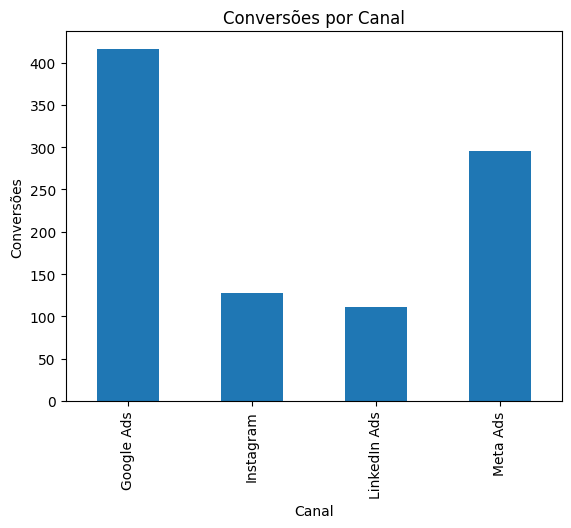

In [30]:
import matplotlib.pyplot as plt

agrupado["conversoes"].plot(kind="bar")

plt.title("Conversões por Canal")
plt.xlabel("Canal")
plt.ylabel("Conversões")
plt.show()

###Análise das Conversões por Canal

Foi elaborado um gráfico de barras com o objetivo de comparar o número de conversões obtidas por cada canal. Para a construção do gráfico, utilizamos a biblioteca Matplotlib em conjunto com o DataFrame agrupado por canal. O auxílio de inteligência artificial foi utilizado nesta etapa para orientar a construção do código e esclarecer o funcionamento dos comandos de visualização, mantendo a análise e a interpretação dos resultados como parte do trabalho.

Observando o gráfico, o Google Ads apresentou o maior número de conversões, com 416, seguido pelo Meta Ads, com 296 conversões. O Instagram apresentou 128 conversões, enquanto o LinkedIn Ads apresentou o menor número, com 111 conversões. Dessa forma, é possível observar uma diferença significativa no volume de conversões entre os canais, com destaque para o desempenho do Google Ads.

Essa visualização é relevante para a estratégia de marketing porque facilita a comparação do desempenho dos canais em relação ao volume de conversões e permite identificar quais plataformas apresentaram maior quantidade de resultados. Entretanto, o número de conversões, isoladamente, não permite avaliar a eficiência de cada canal. Para uma análise mais completa, é necessário considerar também indicadores como taxa de conversão, `CPA`, `ROAS` e o investimento realizado.



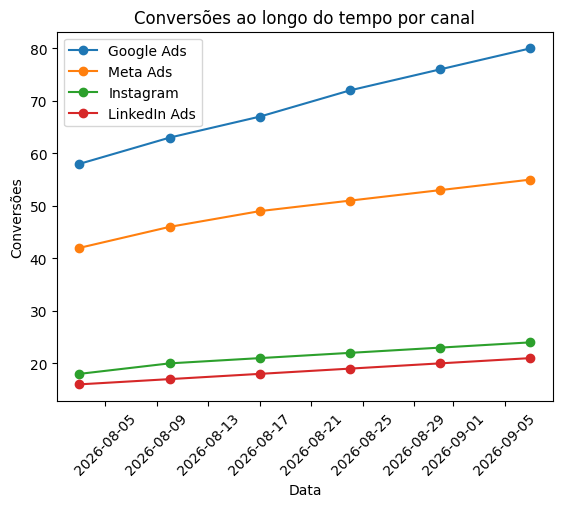

In [31]:
import matplotlib.pyplot as plt

for canal in df["canal"].unique():
    dados_canal = df[df["canal"] == canal]
    plt.plot(dados_canal["data"], dados_canal["conversoes"], marker="o", label=canal)

plt.title("Conversões ao longo do tempo por canal")
plt.xlabel("Data")
plt.ylabel("Conversões")
plt.legend()
plt.xticks(rotation=45)
plt.show()

###Conversões ao longo do tempo por canal


Foi elaborado um gráfico de linhas para acompanhar a evolução das conversões ao longo das datas analisadas, separando os resultados por canal. Para a construção do gráfico, utilizamos o DataFrame original, pois era necessário manter as informações de cada período. O auxílio de inteligência artificial foi utilizado para orientar a construção do código e esclarecer o funcionamento dos comandos utilizados na visualização.

Observando o gráfico, é possível identificar que as conversões variam ao longo das datas e que os canais apresentam comportamentos diferentes durante o período analisado. O Google Ads apresenta os maiores volumes de conversões em determinados períodos, enquanto os demais canais apresentam valores menores e variações próprias ao longo do tempo. Assim, o gráfico permite visualizar períodos de maior e menor desempenho e comparar a evolução dos canais.

Essa visualização é relevante para a estratégia de marketing porque permite acompanhar o desempenho das campanhas ao longo do tempo, identificando períodos de maior ou menor volume de conversões. Essas informações podem auxiliar na avaliação de campanhas e na identificação de momentos que merecem maior atenção.

Entretanto, a variação das conversões, por si só, não permite determinar a causa das mudanças observadas. Para uma análise mais completa, seriam necessárias informações adicionais, como os investimentos realizados em cada período, alterações nas campanhas, ações promocionais e outros fatores que possam ter influenciado o desempenho dos canais.



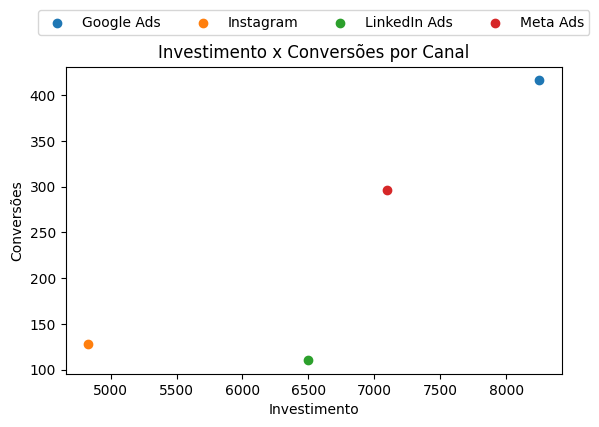

In [19]:
for canal in agrupado.index:
    x = agrupado.loc[canal, "investimento"]
    y = agrupado.loc[canal, "conversoes"]

    plt.scatter(x, y, label=canal)

plt.title("Investimento x Conversões por Canal")
plt.xlabel("Investimento")
plt.ylabel("Conversões")

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4
)

plt.subplots_adjust(top=0.75)

plt.show()

In [20]:
correlacao = df["investimento"].corr(df["conversoes"])

print("Correlação entre investimento e conversões:", round(correlacao, 2))

Correlação entre investimento e conversões: 0.79



### Análise do gráfico de dispersão: Investimento x Conversões por Canal

Foi elaborado um gráfico de dispersão para analisar a relação entre o investimento realizado e o número de conversões obtidas por cada canal. No gráfico, cada ponto representa um canal, permitindo comparar visualmente os valores de investimento e as conversões. O auxílio de inteligência artificial foi utilizado na construção do gráfico, pois não tínhamos conhecimento suficiente para criar esse tipo de visualização e identificar corretamente os canais.

Observando os resultados, o Google Ads apresenta o maior número de conversões (416), acompanhado do maior investimento entre os canais (R$ 8.250). O Meta Ads também apresenta um volume elevado de conversões (296), com investimento de R$ 7.100. Já o Instagram apresenta 128 conversões, com investimento de R$ 4.830, enquanto o LinkedIn Ads apresenta 111 conversões, com investimento de R$ 6.500.

O cálculo da correlação entre investimento e conversões apresentou o valor de **0,79**, indicando uma associação linear positiva relativamente forte neste conjunto de dados. Isso significa que, entre os registros analisados, investimentos mais elevados tendem a estar associados a um maior número de conversões. No entanto, essa relação não é perfeitamente proporcional e não demonstra que o aumento do investimento seja, por si só, a causa do aumento das conversões.

Esta visualização é relevante para a estratégia de marketing porque permite comparar o investimento com o volume de conversões de cada canal, auxiliando na avaliação da distribuição dos recursos entre as plataformas. Para uma análise mais completa, também devem ser considerados indicadores de eficiência, como o custo por aquisição (CPA), a taxa de conversão e o retorno sobre o investimento publicitário (ROAS), além de outros fatores que podem influenciar o desempenho das campanhas.



## Etapa 5 — Insights e Recomendações

### Resultado positivo

**Evidência:** O Google Ads apresentou o melhor desempenho entre os canais analisados, com 416 conversões, taxa de conversão de 2,20%, CPA de R$ 19,83 e ROAS de 7,56.

**Interpretação:** Esses resultados indicam que, neste conjunto de dados, o Google Ads conseguiu gerar um alto volume de conversões utilizando o investimento de forma mais eficiente que os demais canais.

**Decisão proposta:** Manter o Google Ads como um dos principais canais da estratégia e considerar a continuidade dos investimentos realizados nele.

**Forma de validação:** Acompanhar, em períodos futuros, se o canal mantém uma taxa de conversão próxima de 2,20%, CPA próximo ou inferior a R$ 19,83 e ROAS próximo ou superior a 7,56.

### Resultado que merece atenção

**Evidência:** O Instagram apresentou a menor taxa de conversão, de 1,05%, além do menor ROAS, de 2,65. Seu CPA também foi relativamente alto, chegando a R$ 37,73.

**Interpretação:** Esses indicadores sugerem que o Instagram apresentou menor eficiência na geração de conversões em comparação com os outros canais analisados.

**Decisão proposta:** Avaliar a estratégia utilizada no Instagram antes de aumentar os investimentos, buscando identificar possíveis problemas nas campanhas, no público-alvo ou na etapa de conversão.

**Forma de validação:** Realizar novos testes de campanhas e acompanhar a evolução da taxa de conversão, do CPA e do ROAS para verificar se os indicadores apresentam melhora.

### Oportunidade

**Evidência:** O Meta Ads apresentou 296 conversões, com taxa de conversão de 1,92%, CPA de R$ 23,99 e ROAS de 5,20.

**Interpretação:** O canal apresenta um volume relevante de conversões e indicadores de eficiência melhores que Instagram e LinkedIn Ads, embora ainda fique atrás do Google Ads.

**Decisão proposta:** Existe uma oportunidade de testar uma ampliação controlada do investimento em Meta Ads, buscando aumentar o volume de conversões sem comprometer sua eficiência.

**Forma de validação:** Comparar os resultados antes e depois do aumento do investimento, verificando se o número de conversões cresce sem aumento significativo do CPA e sem queda relevante do ROAS.

### Hipótese explicativa

**Evidência:** O Google Ads apresentou simultaneamente a maior taxa de conversão (2,20%), o menor CPA (R$ 19,83) e o maior ROAS (7,56).

**Interpretação:** Uma possível explicação é que o público alcançado pelo Google Ads possa apresentar maior intenção de compra ou maior proximidade da etapa de conversão, fazendo com que os usuários tenham maior probabilidade de realizar uma conversão.

**Decisão proposta:** Considerar a hipótese de que campanhas direcionadas a usuários com maior intenção de compra estejam contribuindo para o melhor desempenho do Google Ads.

**Forma de validação:** Comparar campanhas, públicos e etapas do funil entre os canais, além de acompanhar os resultados de novos períodos para verificar se o padrão de desempenho se mantém.

### Recomendações

**1. Manter e testar a expansão do investimento em Google Ads.**
A recomendação é justificada pelos 416 conversões, pelo CPA de R$ 19,83 e pelo ROAS de 7,56, que foram os melhores resultados entre os canais analisados. A expansão deve ser realizada de forma gradual, acompanhando se o aumento do investimento continua gerando conversões sem reduzir significativamente a eficiência do canal.

**2. Reavaliar o desempenho do Instagram antes de aumentar o investimento.**
O Instagram apresentou a menor taxa de conversão (1,05%) e o menor ROAS (2,65), além de um CPA de R$ 37,73. Dessa forma, recomenda-se testar alterações nas campanhas e no público antes de aumentar os recursos destinados ao canal. A validação pode ser feita comparando os novos resultados de CPA, taxa de conversão e ROAS com os valores observados nesta análise.


# Exercícios

## Diagnóstico dos dados

A base de dados contém 24 registros e 12 variáveis.

* `canal`: variável qualitativa nominal, pois identifica categorias de canais de marketing.
* `investimento`: variável quantitativa contínua, pois representa um valor monetário.
* `data`: variável temporal, pois representa a data de cada registro.
* `conversoes`: variável quantitativa discreta, pois representa uma contagem de conversões.

Foi identificado um valor ausente na coluna `leads`. Também foi identificada uma inconsistência na coluna `canal`, em que a categoria `Instagram` aparecia com um espaço extra no final (`Instagram `). Essa inconsistência foi corrigida com o método `.str.strip()`.

Um valor ausente não significa necessariamente que não houve leads. Pode representar uma falha de registo ou informação não recolhida. Substituí-lo automaticamente por zero poderia distorcer os resultados e levar a conclusões incorretas. Por isso, o valor foi mantido como ausente até que seja possível confirmar o seu significado.

## Métricas de um registro

Para o registo de Google Ads de 03/08/2026, foram calculadas as seguintes métricas:

* **CTR:** 5,00%
* **Taxa de conversão:** 2,23%
* **CPC:** R$ 0,46
* **CPA:** R$ 20,69
* **ROAS:** 7,25

O CTR representa a percentagem de impressões que geraram cliques. A taxa de conversão representa a percentagem de cliques que resultaram em conversões. O CPC indica o custo médio por clique, enquanto o CPA representa o custo médio por conversão. O ROAS indica a receita gerada por cada unidade monetária investida em publicidade.

## Comparação agregada

A comparação foi realizada através da soma dos valores de cada canal e do recálculo das métricas com base nos totais agregados.

O Google Ads possui o maior volume de conversões, com 416 conversões. Também apresenta a maior taxa de conversão, de aproximadamente 2,20%, o maior ROAS, de 7,56, e o menor CPA, de R$ 19,83.

O Instagram merece atenção por apresentar investimento total de R$ 4.830, 128 conversões e ROAS de 2,65, o mais baixo entre os canais. O LinkedIn Ads também merece investigação, pois recebeu R$ 6.500 de investimento, gerou 111 conversões e apresentou o CPA mais elevado, de R$ 58,56. Estes resultados justificam uma análise mais detalhada antes de qualquer alteração definitiva no orçamento.

## Tendência e associação

As conversões não aumentam continuamente em todos os canais. O gráfico de linhas mostra oscilações ao longo do período analisado, indicando que o desempenho varia com o tempo.

A correlação calculada entre o investimento e as conversões nos registos originais foi de aproximadamente **0,79**, indicando uma associação linear positiva relativamente forte entre as duas variáveis.

```python
correlacao = df["investimento"].corr(df["conversoes"])
print(f"Correlação entre investimento e conversões: {correlacao:.2f}")
```

A correlação não prova causalidade. Embora o investimento e as conversões apresentem uma associação positiva, as conversões também podem ser influenciadas por outros fatores, como o canal utilizado, o público-alvo, a qualidade dos anúncios, a sazonalidade e a intenção de compra. Para avaliar se o aumento do investimento provoca um aumento nas conversões, seria necessário realizar testes controlados e considerar outros fatores relevantes.

## Comunicação de insight

### Insights

**Desempenho do Google Ads**

O Google Ads apresentou o maior volume de conversões, com 416 conversões, CPA de R$ 19,83 e ROAS de 7,56. Entre os canais analisados, foi o que combinou maior volume de resultados com menor custo por conversão.

**Atenção ao Instagram**

O Instagram apresentou uma taxa de conversão de 1,05% e ROAS de 2,65, os valores mais baixos entre os canais analisados. Estes resultados indicam a necessidade de investigar o público, os anúncios e a qualidade do tráfego antes de decidir sobre uma alteração no investimento.

**Oportunidade no Meta Ads**

O Meta Ads registou 296 conversões e ROAS de 5,20, mostrando resultados relevantes. Estes números justificam testar a possibilidade de aumentar o investimento de forma controlada, sem assumir antecipadamente que o aumento produzirá melhores resultados.

### Recomendações testáveis

**Testar o orçamento do Meta Ads**

Realizar um teste controlado de aumento de 10% no investimento do Meta Ads, mantendo as restantes condições tão estáveis quanto possível. Comparar as conversões, o CPA e o ROAS antes e durante o teste para verificar se o aumento do orçamento melhora os resultados sem reduzir a eficiência.

**Investigar o desempenho do Instagram**

Testar uma nova versão do anúncio ou uma segmentação de público diferente no Instagram, mantendo um grupo de comparação. Comparar a taxa de conversão, o CPA e o ROAS das duas versões para avaliar se a alteração melhora o desempenho. A decisão deverá basear-se nos resultados observados, e não apenas numa expectativa de melhoria.


### Conclusão

A análise das campanhas de marketing digital permitiu comparar os canais quanto ao volume de conversões, aos custos e ao retorno sobre o investimento publicitário. O Google Ads apresentou o melhor desempenho geral, com 416 conversões, CPA de R$ 19,83 e ROAS de 7,56. O Meta Ads também apresentou resultados relevantes, com 296 conversões e ROAS de 5,20, representando uma oportunidade para testes de crescimento controlado. O Instagram merece atenção por apresentar a menor taxa de conversão, de 1,05%, e o menor ROAS, de 2,65. Recomenda-se testar mudanças gradualmente e acompanhar os indicadores. Como a análise utiliza uma base limitada, os resultados não comprovam causalidade nem garantem o desempenho futuro. O ROAS também não representa lucro, pois não inclui todos os custos do negócio.
